# WRDS + OptionMetrics Results Overview

This notebook is a centralized visualization layer for the saved project outputs. It does **not** rerun WRDS pulls or retrain models. It reads the cached summaries, predictions, processed panels, and raw option files already saved by the pipeline.

The notebook is organized around four questions:
1. How large and clean is the final dataset?
2. How do realized-volatility regimes evolve through time?
3. What do the option-surface state variables look like, both as time series and as actual daily cross-sections?
4. Which models perform best, and why?

In [19]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker
from IPython.display import display, Markdown, Image
import pyarrow.parquet as pq

ROOT = Path.cwd()
if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import (
    ROOT_DIR,
    EXTRACT_STOCK_SUMMARY_PATH,
    BUILD_STOCK_PANEL_SUMMARY_PATH,
    EXTRACT_OPTION_SUMMARY_PATH,
    BUILD_OPTION_FEATURES_SUMMARY_PATH,
    BUILD_SURFACE_FACTORS_SUMMARY_PATH,
    PART1_METRICS_CSV,
    PART1_METRICS_JSON,
    PART1_PREDICTIONS_CSV,
    PART2_METRICS_CSV,
    PART2_METRICS_JSON,
    PART2_PREDICTIONS_CSV,
    SURFACE_EXTENSION_METRICS_CSV,
    SURFACE_EXTENSION_METRICS_JSON,
    SURFACE_EXTENSION_PREDICTIONS_CSV,
    STOCK_PANEL_PATH,
    SURFACE_FACTOR_PANEL_PATH,
    PART2_OPTION_LOGREG_FIGURE,
    PART2_COMBINED_LOGREG_FIGURE,
    SURFACE_ONLY_FIGURE,
    STOCK_SURFACE_FIGURE,
    ALL_FEATURES_FIGURE,
)

NOTEBOOK_SNAPSHOT_PATH = ROOT_DIR / 'data' / 'processed' / 'notebook_surface_snapshots.pkl'

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'semibold',
    'axes.titlesize': 15,
    'axes.labelsize': 12,
    'legend.frameon': False,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

COLORS = {
    'navy': '#143A52',
    'teal': '#2A7F62',
    'gold': '#D9A441',
    'coral': '#C65D52',
    'slate': '#6C7A89',
    'ink': '#1B263B',
    'mist': '#DCE6F1',
}

SPLIT_LINES = {
    'Train end': pd.Timestamp('2021-12-31'),
    'Validation end': pd.Timestamp('2022-12-31'),
}

MODEL_LABELS = {
    'persistence_baseline': 'Persistence baseline',
    'stock_only_logreg': 'Stock-only logistic',
    'stock_only_logreg_complete_case': 'Stock-only logistic (complete-case)',
    'option_only_logreg': 'Option-only logistic',
    'combined_logreg': 'Stock + option logistic',
    'stock_only_logreg_surface_common': 'Stock-only logistic (surface-common panel)',
    'option_only_logreg_surface_common': 'Option-only logistic (surface-common panel)',
    'combined_original_logreg_surface_common': 'Stock + original option logistic',
    'surface_only_logreg': 'Surface-only logistic',
    'stock_surface_logreg': 'Stock + surface logistic',
    'all_features_logreg': 'Stock + option + surface logistic',
}

def load_json(path: Path):
    return json.loads(path.read_text(encoding='utf-8'))

def safe_read_parquet(path: Path, columns=None):
    pickle_path = path.with_suffix('.pkl')
    if pickle_path.exists() and columns is None:
        return pd.read_pickle(pickle_path)
    try:
        return pd.read_parquet(path, columns=columns)
    except Exception:
        table = pq.read_table(path, columns=columns, memory_map=False)
        return table.to_pandas()

def fmt_pct(x, pos=None):
    return f'{100 * x:.0f}%'

def add_split_lines(ax):
    for label, date in SPLIT_LINES.items():
        ax.axvline(date, color=COLORS['slate'], linestyle='--', linewidth=1.2, alpha=0.8, label=label)
    handles, labels = ax.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    ax.legend(unique.values(), unique.keys(), loc='best')

def top_abs_coef(rows, top_n=10):
    frame = pd.DataFrame(rows).copy()
    frame['abs_coef'] = frame['coefficient'].abs()
    return frame.sort_values('abs_coef', ascending=False).head(top_n).sort_values('coefficient')

display(Markdown(f'**Project root:** `{ROOT_DIR}`'))
display(Markdown(f'**Notebook kernel working directory:** `{ROOT}`'))

**Project root:** `C:\Users\xxtri\Desktop\Machine Learning\PROJECT\wrds_optionmetrics_exploration`

**Notebook kernel working directory:** `c:\Users\xxtri\Desktop\Machine Learning\PROJECT\wrds_optionmetrics_exploration`

In [20]:
stock_extract = load_json(EXTRACT_STOCK_SUMMARY_PATH)
stock_panel_summary = load_json(BUILD_STOCK_PANEL_SUMMARY_PATH)
option_extract = load_json(EXTRACT_OPTION_SUMMARY_PATH)
option_build = load_json(BUILD_OPTION_FEATURES_SUMMARY_PATH)
surface_build = load_json(BUILD_SURFACE_FACTORS_SUMMARY_PATH)
part1_json = load_json(PART1_METRICS_JSON)
part2_json = load_json(PART2_METRICS_JSON)
surface_json = load_json(SURFACE_EXTENSION_METRICS_JSON)

part1_metrics = pd.read_csv(PART1_METRICS_CSV)
part2_metrics = pd.read_csv(PART2_METRICS_CSV)
surface_metrics = pd.read_csv(SURFACE_EXTENSION_METRICS_CSV)

part1_predictions = pd.read_csv(PART1_PREDICTIONS_CSV, parse_dates=['trade_date'])
part2_predictions = pd.read_csv(PART2_PREDICTIONS_CSV, parse_dates=['trade_date'])
surface_predictions = pd.read_csv(SURFACE_EXTENSION_PREDICTIONS_CSV, parse_dates=['trade_date'])

stock_panel = safe_read_parquet(STOCK_PANEL_PATH)
stock_panel['trade_date'] = pd.to_datetime(stock_panel['trade_date'])
surface_panel = safe_read_parquet(SURFACE_FACTOR_PANEL_PATH)
surface_panel['trade_date'] = pd.to_datetime(surface_panel['trade_date'])

coverage = pd.DataFrame([
    {'Stage': 'Stock extract', 'Rows': stock_extract['stock_daily_rows'], 'Entities': stock_extract['resolved_permnos'], 'Description': 'CRSP daily stock rows'},
    {'Stage': 'Stock panel', 'Rows': stock_panel_summary['panel_rows'], 'Entities': stock_panel_summary['permno_count'], 'Description': 'Final stock-day panel'},
    {'Stage': 'Option extract', 'Rows': option_extract['option_price_rows'], 'Entities': option_extract['secid_count'], 'Description': 'Raw OptionMetrics contract-day rows'},
    {'Stage': 'Option feature panel', 'Rows': option_build['option_feature_rows'], 'Entities': option_extract['permno_count'], 'Description': 'Daily option features'},
    {'Stage': 'Complete-case panel', 'Rows': option_build['complete_case_rows'], 'Entities': stock_panel_summary['permno_count'], 'Description': 'Part 2 comparison panel'},
    {'Stage': 'Surface factor panel', 'Rows': surface_build['surface_panel_rows'], 'Entities': np.nan, 'Description': 'Daily surface descriptors'},
    {'Stage': 'Surface common panel', 'Rows': sum(surface_json['split_sizes'].values()), 'Entities': np.nan, 'Description': 'Surface extension comparison panel'},
])

coverage_display = coverage.copy()
coverage_display['Rows'] = coverage_display['Rows'].map(lambda x: f'{int(x):,}')
coverage_display['Entities'] = coverage_display['Entities'].map(lambda x: '' if pd.isna(x) else f'{int(x):,}')

display(Markdown('## Coverage Snapshot'))
display(coverage_display)

## Coverage Snapshot

,Stage,Rows,Entities,Description
0,Stock extract,"217,571",101,CRSP daily stock rows
1,Stock panel,"213,786",97,Final stock-day panel
2,Option extract,"262,252,896",138,Raw OptionMetrics contract-day rows
3,Option feature panel,"224,212",101,Daily option features
4,Complete-case panel,"178,217",97,Part 2 comparison panel
5,Surface factor panel,"224,317",,Daily surface descriptors
6,Surface common panel,"177,204",,Surface extension comparison panel


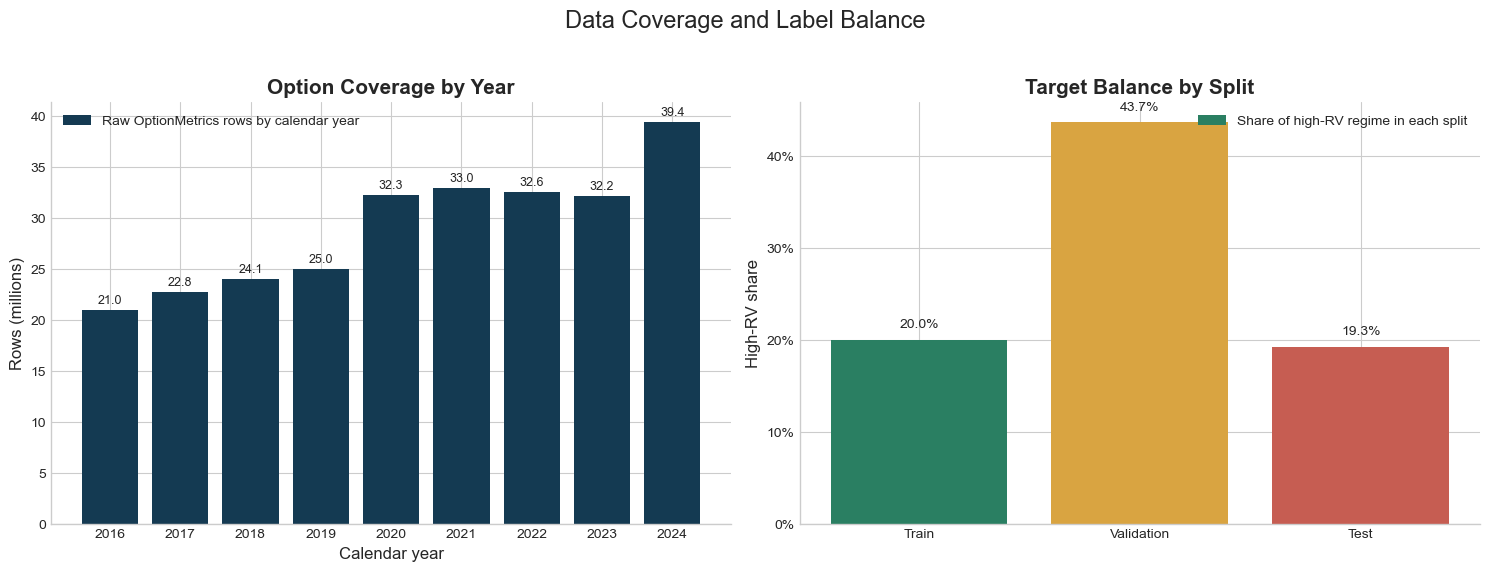

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

rows_by_year = pd.Series(option_extract['option_price_rows_by_year']).astype(int).sort_index()
bars = axes[0].bar(rows_by_year.index.astype(str), rows_by_year.values / 1_000_000, color=COLORS['navy'], label='Raw OptionMetrics rows by calendar year')
axes[0].set_title('Option Coverage by Year')
axes[0].set_xlabel('Calendar year')
axes[0].set_ylabel('Rows (millions)')
axes[0].legend(loc='upper left')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.35, f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

split_share = pd.Series(stock_panel_summary['positive_share_by_split'])
bars2 = axes[1].bar(split_share.index.str.title(), split_share.values, color=[COLORS['teal'], COLORS['gold'], COLORS['coral']], label='Share of high-RV regime in each split')
axes[1].set_title('Target Balance by Split')
axes[1].set_ylabel('High-RV share')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(fmt_pct))
axes[1].legend(loc='upper right')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Data Coverage and Label Balance', y=1.03, fontsize=17)
plt.tight_layout()
plt.show()

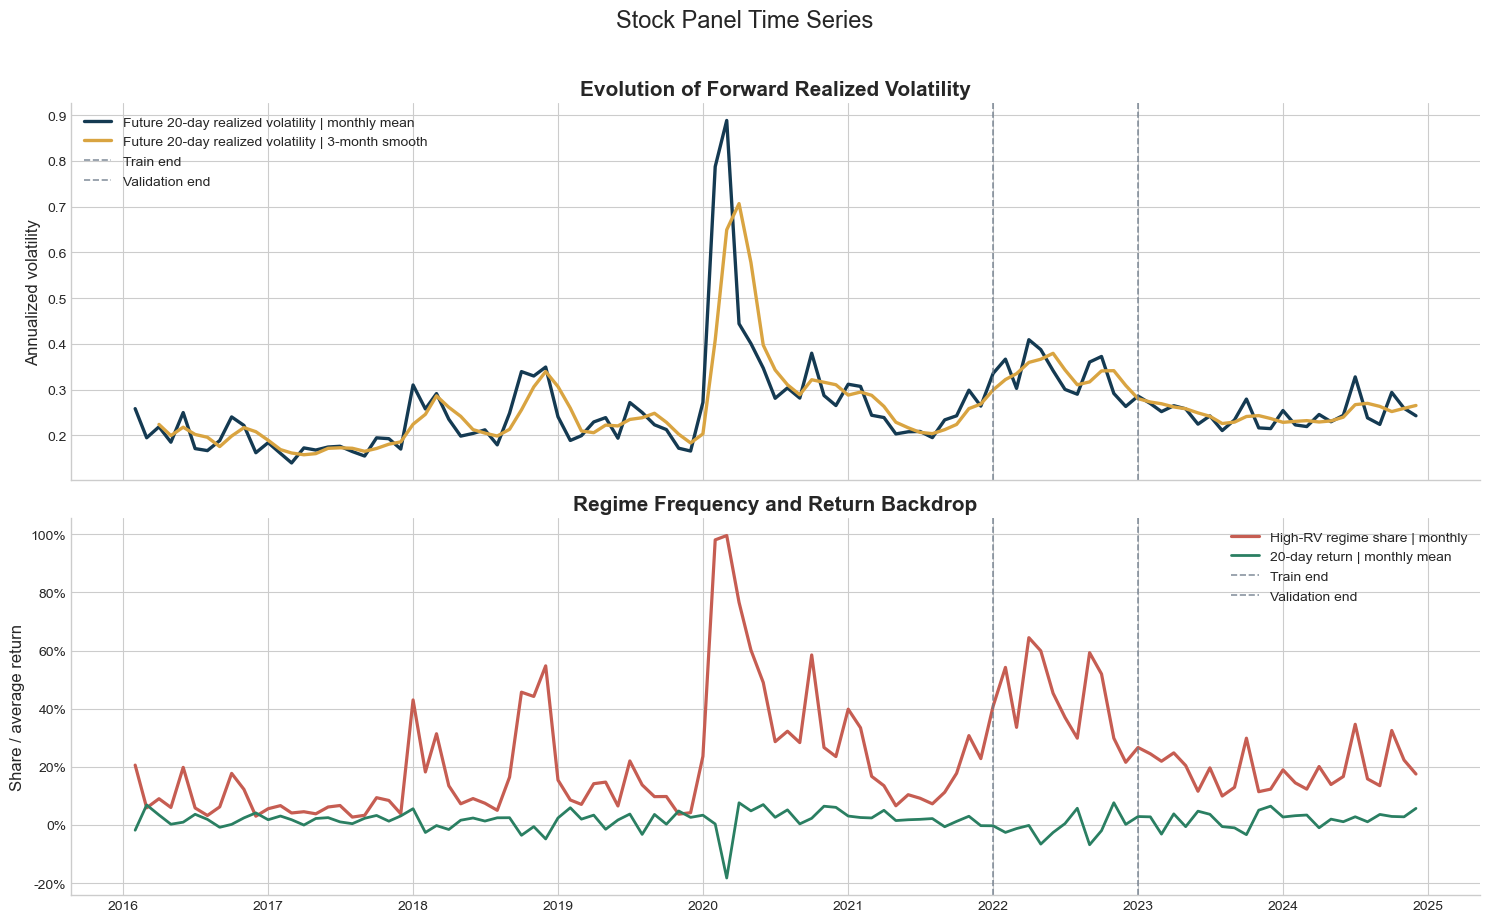

In [22]:
monthly_stock = (
    stock_panel
    .assign(month=lambda df: df['trade_date'].dt.to_period('M').dt.to_timestamp())
    .groupby('month', as_index=False)
    .agg(
        future_rv_20d_mean=('future_rv_20d', 'mean'),
        high_rv_share=('high_rv_regime', 'mean'),
        ret_20d_mean=('ret_20d', 'mean'),
    )
)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

axes[0].plot(monthly_stock['month'], monthly_stock['future_rv_20d_mean'], color=COLORS['navy'], linewidth=2.4, label='Future 20-day realized volatility | monthly mean')
axes[0].plot(monthly_stock['month'], monthly_stock['future_rv_20d_mean'].rolling(3).mean(), color=COLORS['gold'], linewidth=2.4, label='Future 20-day realized volatility | 3-month smooth')
axes[0].set_title('Evolution of Forward Realized Volatility')
axes[0].set_ylabel('Annualized volatility')
add_split_lines(axes[0])

axes[1].plot(monthly_stock['month'], monthly_stock['high_rv_share'], color=COLORS['coral'], linewidth=2.3, label='High-RV regime share | monthly')
axes[1].plot(monthly_stock['month'], monthly_stock['ret_20d_mean'], color=COLORS['teal'], linewidth=2.0, label='20-day return | monthly mean')
axes[1].set_title('Regime Frequency and Return Backdrop')
axes[1].set_ylabel('Share / average return')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:.0%}' if abs(x) <= 1.0 else f'{x:.2f}'))
add_split_lines(axes[1])

plt.suptitle('Stock Panel Time Series', y=1.02, fontsize=17)
plt.tight_layout()
plt.show()

## Surface Factors Through Time

These are the smoothed surface variables used by the extension model. They are not just summary tables: the time series below show how the option-implied state evolves across the sample.

- `surface_atm_short`: short-dated ATM implied volatility
- `surface_term_slope`: long ATM IV minus short ATM IV
- `surface_rr_25_short`: 25-delta call IV minus 25-delta put IV
- `surface_bf_25_short`: 25-delta butterfly curvature

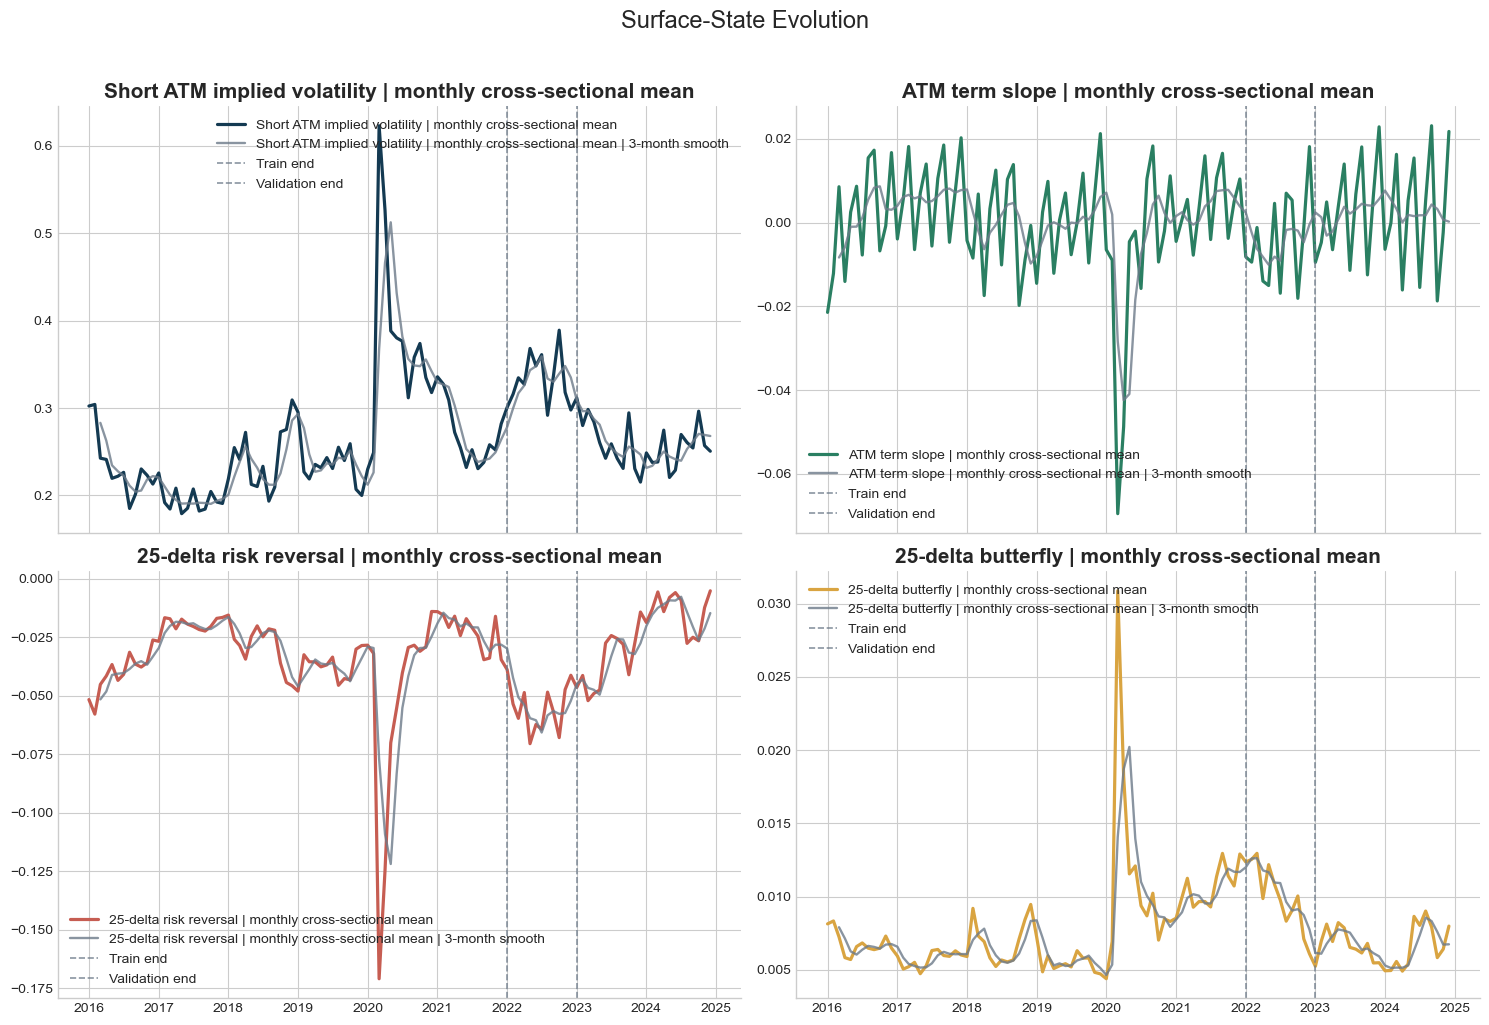

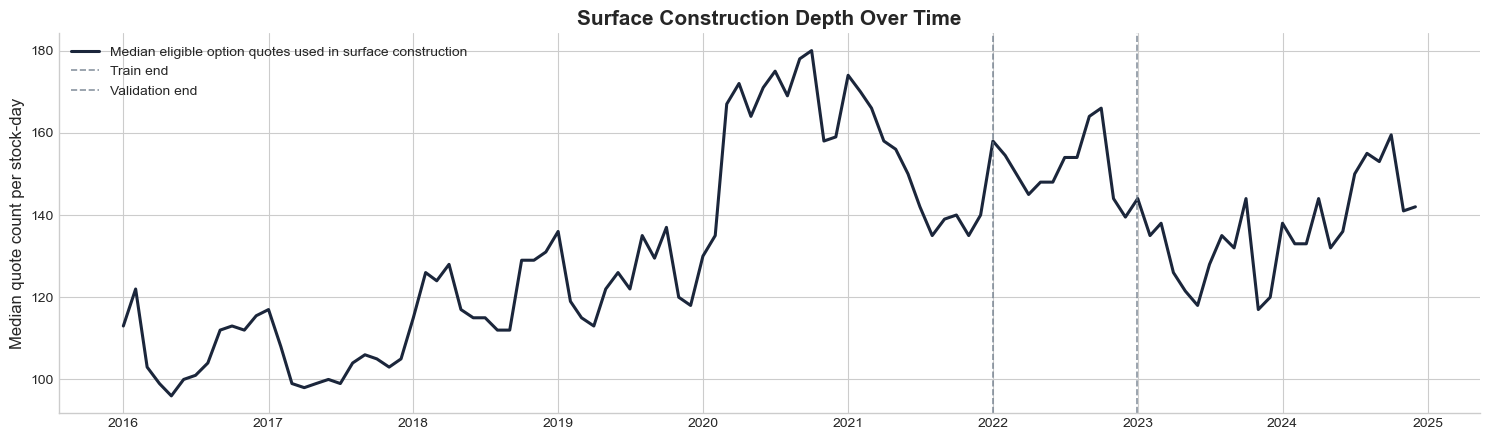

In [23]:
monthly_surface = (
    surface_panel
    .assign(month=lambda df: df['trade_date'].dt.to_period('M').dt.to_timestamp())
    .groupby('month', as_index=False)
    .agg(
        surface_atm_short=('surface_atm_short', 'mean'),
        surface_term_slope=('surface_term_slope', 'mean'),
        surface_rr_25_short=('surface_rr_25_short', 'mean'),
        surface_bf_25_short=('surface_bf_25_short', 'mean'),
        surface_quote_count=('surface_quote_count', 'median'),
    )
)

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
plot_specs = [
    ('surface_atm_short', 'Short ATM implied volatility | monthly cross-sectional mean', COLORS['navy']),
    ('surface_term_slope', 'ATM term slope | monthly cross-sectional mean', COLORS['teal']),
    ('surface_rr_25_short', '25-delta risk reversal | monthly cross-sectional mean', COLORS['coral']),
    ('surface_bf_25_short', '25-delta butterfly | monthly cross-sectional mean', COLORS['gold']),
]
for ax, (col, label, color) in zip(axes.flat, plot_specs):
    ax.plot(monthly_surface['month'], monthly_surface[col], color=color, linewidth=2.3, label=label)
    ax.plot(monthly_surface['month'], monthly_surface[col].rolling(3).mean(), color=COLORS['slate'], linewidth=1.7, alpha=0.8, label=f'{label} | 3-month smooth')
    ax.set_title(label)
    add_split_lines(ax)

plt.suptitle('Surface-State Evolution', y=1.02, fontsize=17)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(15, 4.5))
ax.plot(monthly_surface['month'], monthly_surface['surface_quote_count'], color=COLORS['ink'], linewidth=2.2, label='Median eligible option quotes used in surface construction')
ax.set_title('Surface Construction Depth Over Time')
ax.set_ylabel('Median quote count per stock-day')
add_split_lines(ax)
plt.tight_layout()
plt.show()

## Daily Implied-Volatility Surface Snapshots

The extension does **not** fit a full parametric volatility-surface model. Instead, it builds a robust daily surface state from filtered option quotes and then smooths those state variables over time.

The two plots below still let you inspect the actual implied-volatility cross-section used for that surface state. The x-axis is days to expiry, the y-axis is signed delta, and the color scale is implied volatility.

C:\Users\xxtri\AppData\Local\Temp\ipykernel_160332\135811544.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


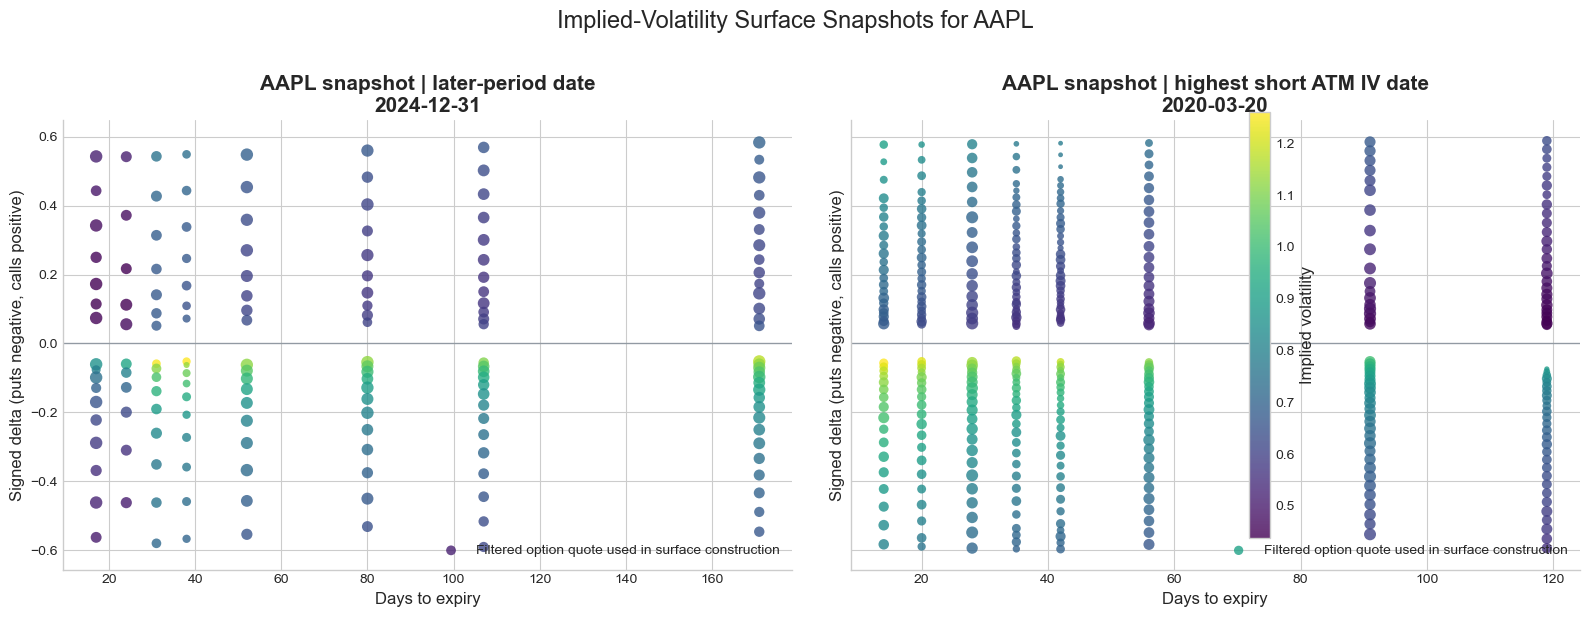

In [24]:
snapshot_data = pd.read_pickle(NOTEBOOK_SNAPSHOT_PATH)
snapshot_data['trade_date'] = pd.to_datetime(snapshot_data['trade_date'])
snapshot_data['exdate'] = pd.to_datetime(snapshot_data['exdate'])
snapshot_data['snapshot_date'] = pd.to_datetime(snapshot_data['snapshot_date'])
sample_ticker = snapshot_data['sample_ticker'].iloc[0]
snapshot_labels = [
    ('later_period', f'{sample_ticker} snapshot | later-period date'),
    ('stress_period', f'{sample_ticker} snapshot | highest short ATM IV date'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for ax, (snapshot_label, title) in zip(axes, snapshot_labels):
    snap = snapshot_data[snapshot_data['snapshot_label'] == snapshot_label].copy()
    snapshot_date = pd.Timestamp(snap['snapshot_date'].iloc[0])
    sc = ax.scatter(
        snap['dte'],
        snap['signed_delta'],
        c=snap['impl_volatility'],
        s=np.clip(np.log1p(snap['open_interest']) * 8, 12, 80),
        cmap='viridis',
        alpha=0.8,
        edgecolor='none',
        label='Filtered option quote used in surface construction',
    )
    ax.set_title(f'{title}\n{pd.Timestamp(snapshot_date).date().isoformat()}')
    ax.set_xlabel('Days to expiry')
    ax.set_ylabel('Signed delta (puts negative, calls positive)')
    ax.axhline(0, color=COLORS['slate'], linewidth=1, alpha=0.6)
    ax.legend(loc='lower right')

cbar = fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.92)
cbar.set_label('Implied volatility')
plt.suptitle(f'Implied-Volatility Surface Snapshots for {sample_ticker}', y=1.02, fontsize=17)
plt.tight_layout()
plt.show()

## Test-Set Model Comparison

,stage,model_label,macro_f1,pr_auc,auroc,balanced_accuracy
0,Surface extension,Stock + option + surface logistic,0.7548,0.7136,0.8807,0.7215
1,Surface extension,Stock + original option logistic,0.7530,0.7101,0.8791,0.7197
2,Part 2,Stock + option logistic,0.7531,0.7096,0.8790,0.7198
3,Surface extension,Option-only logistic (surface-common panel),0.7541,0.7096,0.8794,0.7211
4,Part 2,Option-only logistic,0.7539,0.7092,0.8793,0.7209
5,Surface extension,Surface-only logistic,0.7526,0.7032,0.8770,0.7194
6,Surface extension,Stock + surface logistic,0.7508,0.7019,0.8764,0.7176
7,Surface extension,Stock-only logistic (surface-common panel),0.6276,0.5031,0.7467,0.6074
8,Part 2,Stock-only logistic (complete-case),0.6274,0.5024,0.7465,0.6072
9,Part 1,Stock-only logistic,0.6265,0.4875,0.7504,0.6048


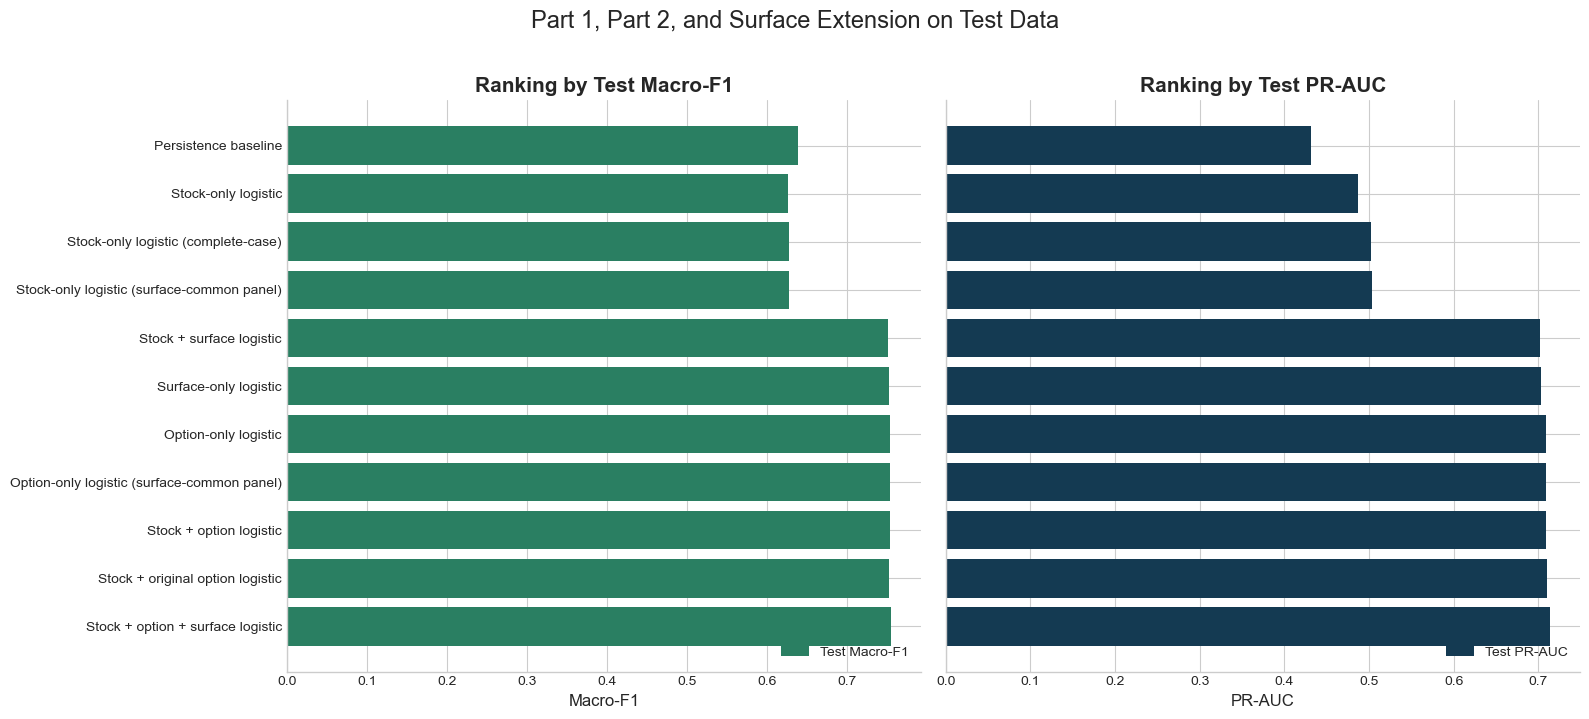

In [25]:
all_test = pd.concat([
    part1_metrics.query("split == 'test'").assign(stage='Part 1'),
    part2_metrics.query("split == 'test'").assign(stage='Part 2'),
    surface_metrics.query("split == 'test'").assign(stage='Surface extension'),
], ignore_index=True)
all_test['model_label'] = all_test['model'].map(MODEL_LABELS).fillna(all_test['model'])
ranked = all_test.sort_values(['pr_auc', 'macro_f1'], ascending=False).reset_index(drop=True)

display(Markdown('## Test-Set Model Comparison'))
display(ranked[['stage', 'model_label', 'macro_f1', 'pr_auc', 'auroc', 'balanced_accuracy']].style.format({
    'macro_f1': '{:.4f}', 'pr_auc': '{:.4f}', 'auroc': '{:.4f}', 'balanced_accuracy': '{:.4f}'
}))

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
y = np.arange(len(ranked))

axes[0].barh(y, ranked['macro_f1'], color=COLORS['teal'], label='Test Macro-F1')
axes[0].set_yticks(y)
axes[0].set_yticklabels(ranked['model_label'])
axes[0].invert_yaxis()
axes[0].set_title('Ranking by Test Macro-F1')
axes[0].set_xlabel('Macro-F1')
axes[0].legend(loc='lower right')

axes[1].barh(y, ranked['pr_auc'], color=COLORS['navy'], label='Test PR-AUC')
axes[1].set_yticks(y)
axes[1].set_yticklabels(ranked['model_label'])
axes[1].invert_yaxis()
axes[1].set_title('Ranking by Test PR-AUC')
axes[1].set_xlabel('PR-AUC')
axes[1].legend(loc='lower right')

plt.suptitle('Part 1, Part 2, and Surface Extension on Test Data', y=1.02, fontsize=17)
plt.tight_layout()
plt.show()

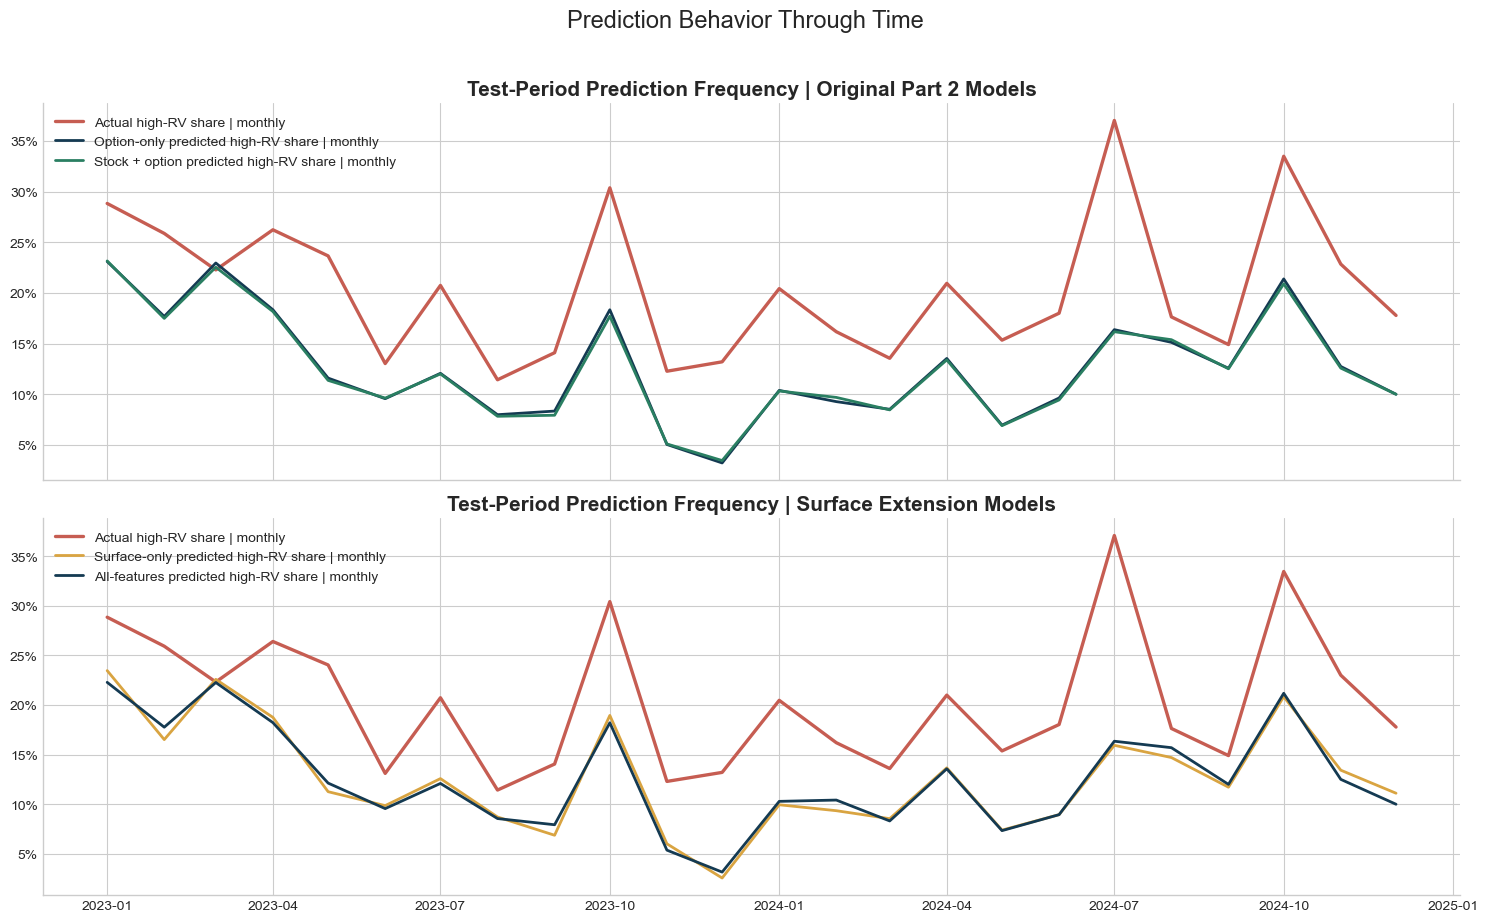

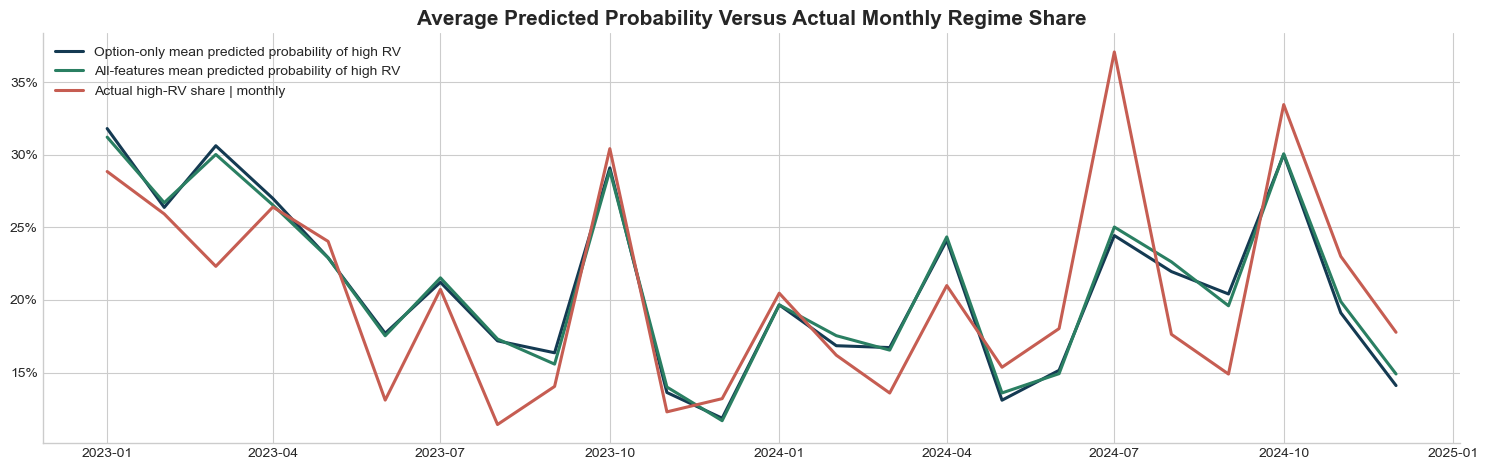

In [26]:
test_part2 = part2_predictions.query("split == 'test'").copy()
test_surface = surface_predictions.query("split == 'test'").copy()

monthly_part2 = (
    test_part2.assign(month=lambda df: df['trade_date'].dt.to_period('M').dt.to_timestamp())
    .groupby('month', as_index=False)
    .agg(
        actual_high_rv_share=('label', 'mean'),
        option_only_pred_share=('option_only_pred', 'mean'),
        option_only_prob_mean=('option_only_prob', 'mean'),
        combined_pred_share=('combined_pred', 'mean'),
    )
)

monthly_surface_pred = (
    test_surface.assign(month=lambda df: df['trade_date'].dt.to_period('M').dt.to_timestamp())
    .groupby('month', as_index=False)
    .agg(
        actual_high_rv_share=('label', 'mean'),
        surface_only_pred_share=('surface_only_pred', 'mean'),
        all_features_pred_share=('all_features_pred', 'mean'),
        all_features_prob_mean=('all_features_prob', 'mean'),
    )
)

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
axes[0].plot(monthly_part2['month'], monthly_part2['actual_high_rv_share'], color=COLORS['coral'], linewidth=2.4, label='Actual high-RV share | monthly')
axes[0].plot(monthly_part2['month'], monthly_part2['option_only_pred_share'], color=COLORS['navy'], linewidth=2.0, label='Option-only predicted high-RV share | monthly')
axes[0].plot(monthly_part2['month'], monthly_part2['combined_pred_share'], color=COLORS['teal'], linewidth=2.0, label='Stock + option predicted high-RV share | monthly')
axes[0].set_title('Test-Period Prediction Frequency | Original Part 2 Models')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(fmt_pct))
axes[0].legend(loc='best')

axes[1].plot(monthly_surface_pred['month'], monthly_surface_pred['actual_high_rv_share'], color=COLORS['coral'], linewidth=2.4, label='Actual high-RV share | monthly')
axes[1].plot(monthly_surface_pred['month'], monthly_surface_pred['surface_only_pred_share'], color=COLORS['gold'], linewidth=2.0, label='Surface-only predicted high-RV share | monthly')
axes[1].plot(monthly_surface_pred['month'], monthly_surface_pred['all_features_pred_share'], color=COLORS['navy'], linewidth=2.0, label='All-features predicted high-RV share | monthly')
axes[1].set_title('Test-Period Prediction Frequency | Surface Extension Models')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(fmt_pct))
axes[1].legend(loc='best')

plt.suptitle('Prediction Behavior Through Time', y=1.02, fontsize=17)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(15, 4.8))
ax.plot(monthly_part2['month'], monthly_part2['option_only_prob_mean'], color=COLORS['navy'], linewidth=2.2, label='Option-only mean predicted probability of high RV')
ax.plot(monthly_surface_pred['month'], monthly_surface_pred['all_features_prob_mean'], color=COLORS['teal'], linewidth=2.2, label='All-features mean predicted probability of high RV')
ax.plot(monthly_surface_pred['month'], monthly_surface_pred['actual_high_rv_share'], color=COLORS['coral'], linewidth=2.2, label='Actual high-RV share | monthly')
ax.set_title('Average Predicted Probability Versus Actual Monthly Regime Share')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(fmt_pct))
ax.legend(loc='best')
plt.tight_layout()
plt.show()

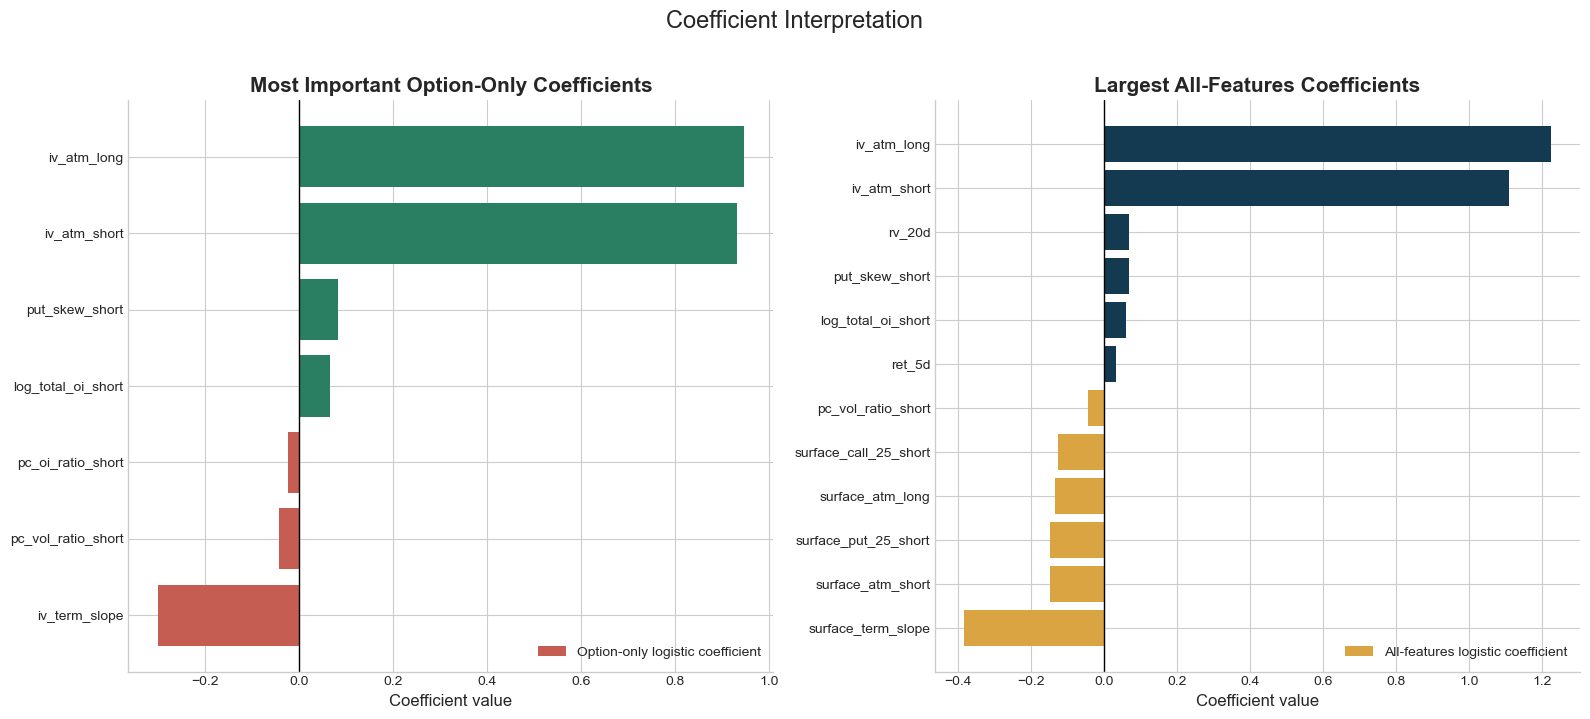

In [27]:
option_coef = top_abs_coef(part2_json['option_only_coefficients'], top_n=7)
all_coef = top_abs_coef(surface_json['all_features_coefficients'], top_n=12)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(option_coef['feature'], option_coef['coefficient'], color=np.where(option_coef['coefficient'] >= 0, COLORS['teal'], COLORS['coral']), label='Option-only logistic coefficient')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Most Important Option-Only Coefficients')
axes[0].set_xlabel('Coefficient value')
axes[0].legend(loc='lower right')

axes[1].barh(all_coef['feature'], all_coef['coefficient'], color=np.where(all_coef['coefficient'] >= 0, COLORS['navy'], COLORS['gold']), label='All-features logistic coefficient')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Largest All-Features Coefficients')
axes[1].set_xlabel('Coefficient value')
axes[1].legend(loc='lower right')

plt.suptitle('Coefficient Interpretation', y=1.02, fontsize=17)
plt.tight_layout()
plt.show()

## Saved Confusion Matrices

### Part 2 | Option-only logistic confusion matrix

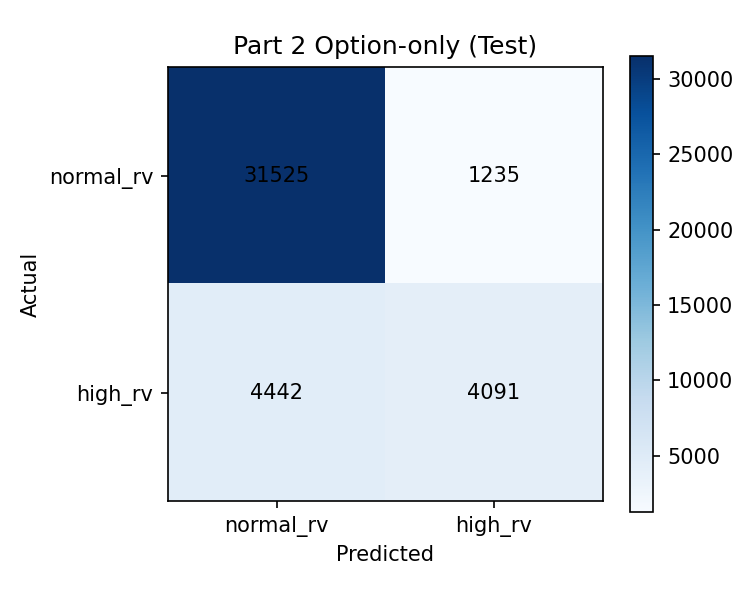

### Part 2 | Stock + option logistic confusion matrix

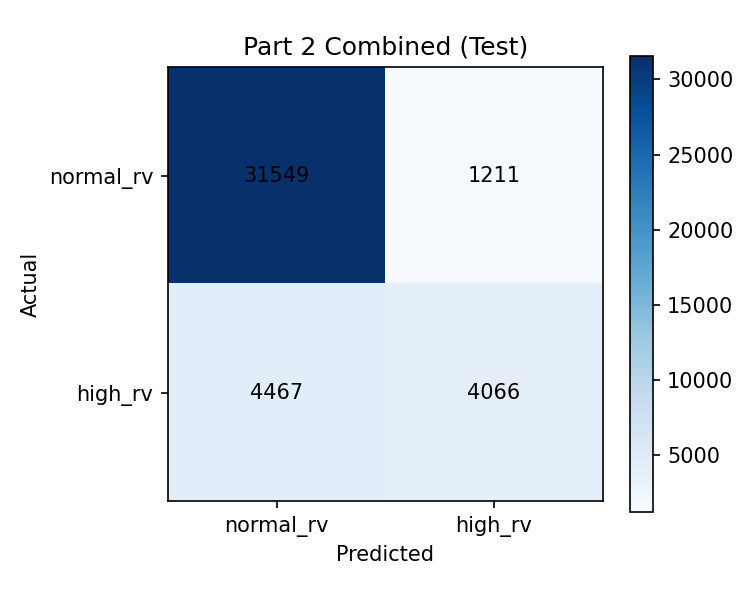

### Surface extension | Surface-only logistic confusion matrix

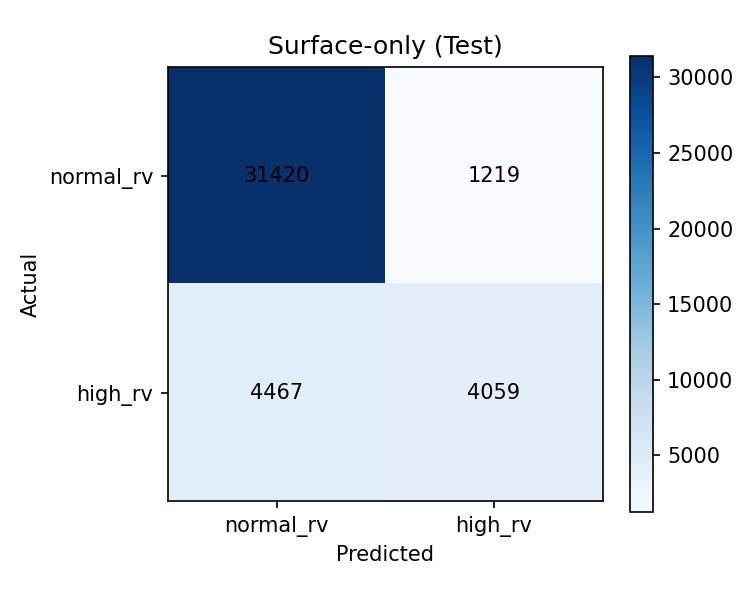

### Surface extension | Stock + surface logistic confusion matrix

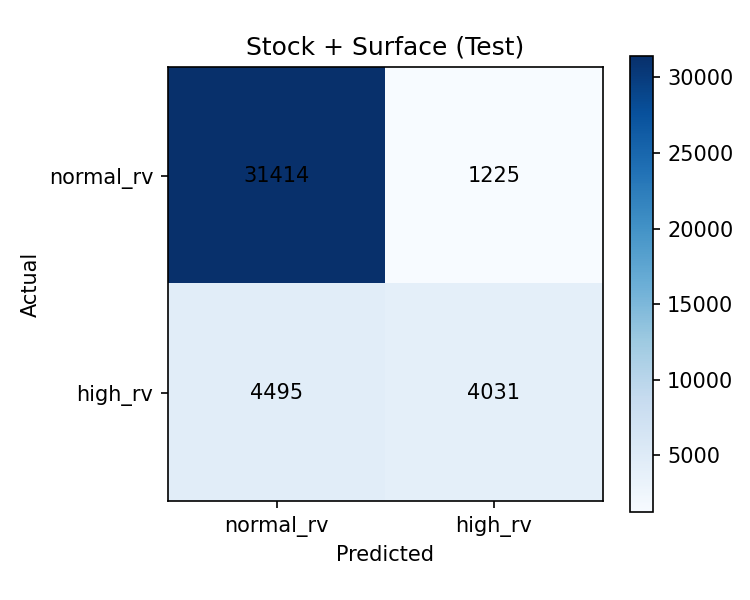

### Surface extension | All-features logistic confusion matrix

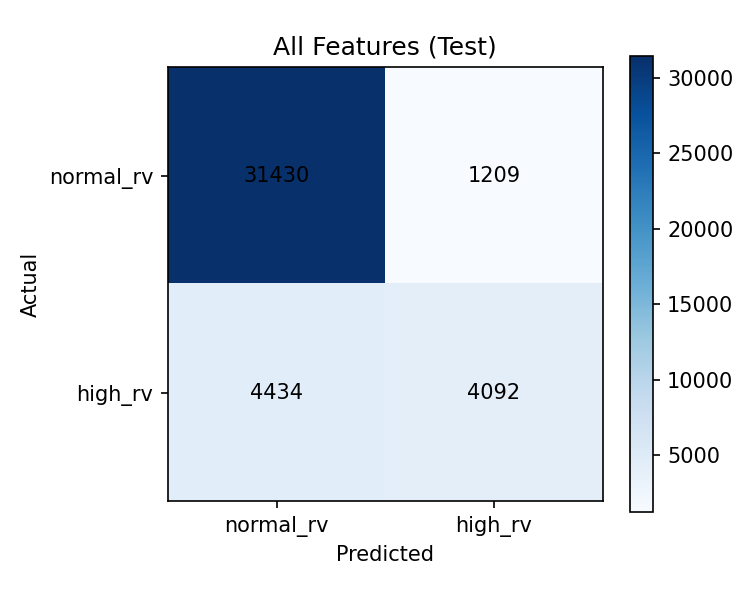

In [28]:
display(Markdown('## Saved Confusion Matrices'))
for figure_path, title in [
    (PART2_OPTION_LOGREG_FIGURE, 'Part 2 | Option-only logistic confusion matrix'),
    (PART2_COMBINED_LOGREG_FIGURE, 'Part 2 | Stock + option logistic confusion matrix'),
    (SURFACE_ONLY_FIGURE, 'Surface extension | Surface-only logistic confusion matrix'),
    (STOCK_SURFACE_FIGURE, 'Surface extension | Stock + surface logistic confusion matrix'),
    (ALL_FEATURES_FIGURE, 'Surface extension | All-features logistic confusion matrix'),
]:
    display(Markdown(f'### {title}'))
    display(Image(filename=str(figure_path)))

## Interpretation

The visuals support the same main conclusion as the metric files, but more clearly.

- The stock-only baseline is stable but limited. It captures persistence in volatility, but it remains clearly weaker than the option-based models.
- The original OptionMetrics feature set is already strong. On the complete-case panel, option-only performance is materially above stock-only performance.
- The surface extension adds a meaningful refinement. The daily surface-state variables are strong on their own, and the combined all-features model is the best overall test model.
- The surface snapshots make the extension more interpretable: the model is not relying on arbitrary engineered numbers, but on a disciplined state representation derived from filtered option quotes across delta and maturity.
- The coefficient plots remain financially sensible. ATM implied volatility levels and closely related surface-state variables dominate the predictive signal for future high-realized-volatility regimes.

**Bottom line:** option-implied information remains the primary driver of predictive power, and the surface-based extension improves the project by making that option-state information richer, smoother, and more interpretable.